In [2]:
# Install opendatasets package
!pip install opendatasets

In [3]:
# Import opendataset libraries
import opendatasets as od

In [4]:
# Download the Dataset
od.download('https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia?select=chest_xray')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Ronok Rahman
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


100%|██████████| 2.29G/2.29G [02:09<00:00, 19.0MB/s]


In [18]:
# Import Required Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import AlexNet_Weights
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import numpy as np
import os
import copy


In [6]:
# Select a Device
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [7]:
# Store the pathway of dataset
train_dir='/content/chest-xray-pneumonia/chest_xray/train'
test_dir='/content/chest-xray-pneumonia/chest_xray/test'
val_dir='/content/chest-xray-pneumonia/chest_xray/val'

In [8]:
# Preprocessing: Transform the train dataset
train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [9]:
# Preprocessing: Transform the validation dataset
val_transform=transforms.Compose([
    transforms.Resize((242,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

In [10]:
# Preprocessing: Transform the test dataset
test_transform=val_transform

In [11]:
# Creates Dataset
train_dataset=datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)
val_dataset=datasets.ImageFolder(
    root=val_dir,
    transform=val_transform
)
test_dataset=datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)


In [17]:
# Load Dataset to model using DataLoader
batch_size=32
train_loader=DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)
val_loader=DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False
)
test_loader=DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [13]:
# Import Alexnet model

# Extract Default weights of AlexNet
weights=AlexNet_Weights.DEFAULT

# Creates Alexnet model object
model=models.alexnet(weights=weights)

# Stop gradient calculation
for param in model.features.parameters():
  param.requires_grad=False

# Modified last layer as binary classification
model.classifier[6]=nn.Linear(4096, 2)

# Send the model to device
model=model.to(device)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 180MB/s]


In [15]:
# Calculate Loss and Optimize the model
# Creates Loss objective
criterion=nn.CrossEntropyLoss()

# Create optimizer object
optimizer=optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001,
    weight_decay=0.0001
)

# Crreate a object of learningRate Schedule
scheduler=optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=5
)
# prevent gradients from becoming too small using Gradscaler
scaler=torch.amp.GradScaler('cuda')


In [21]:
# Training the model
epochs=20
patience=5
best_acc=0
counter=0

train_loss_history=[]
val_loss_history=[]
train_acc_history=[]
val_acc_history=[]

# Copy the best weights
best_weights=copy.deepcopy(model.state_dict())

for epoch in range(epochs):
  print(f"\nEpoch {epoch+1}/{epochs}")

  # Train
  model.train()
  running_loss=0
  running_correct=0
  train_bar=tqdm(train_loader)

  # Load images
  for images, labels in train_bar:
    images=images.to(device)
    labels=labels.to(device)
    optimizer.zero_grad()

    # Forward Pass, Loss Calculation, Backpropagation, and Optimizer Update
    with torch.amp.autocast('cuda'):
      outputs=model(images)
      loss=criterion(outputs, labels)
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    # Get Predicted Class
    _, preds=torch.max(outputs, 1)

    # Add Batch Loss
    running_loss+=loss.item()*images.size(0)
    # Count Correct Predictions
    running_correct+=torch.sum(preds==labels)
    # Update Progress Bar
    train_bar.set_postfix(loss=loss.item(), acc=running_correct.item()/len(train_dataset))

  # Calculate Average Training Loss and accurcay
  epoch_train_acc=running_correct.double()/len(train_dataset)
  epoch_train_loss=running_loss/len(train_dataset)

  # Validation
  model.eval()
  val_loss=0
  val_correct=0

  with torch.no_grad():
    val_bar=tqdm(val_loader)
    for images, labels in val_bar:
      images=images.to(device)
      labels=labels.to(device)
      outputs=model(images)
      loss=criterion(outputs, labels)
      _, preds=torch.max(outputs, 1)
      val_loss+=loss.item()*images.size(0)
      val_correct+=torch.sum(preds==labels)

  epoch_val_loss = val_loss/len(val_dataset)
  epoch_val_acc = val_correct.double()/len(val_dataset)

  # Update Learning Rate and Save Training History
  scheduler.step(epoch_val_loss)

  train_loss_history.append(epoch_train_loss)
  val_loss_history.append(epoch_val_loss)
  train_acc_history.append(epoch_train_acc.cpu())
  val_acc_history.append(epoch_val_acc.cpu())

  print(f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}")
  print(f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

  # Save the Best Model
  if epoch_val_acc>best_acc:
    best_acc=epoch_val_acc
    best_weights=copy.deepcopy(model.state_dict())
    torch.save(best_weights, 'best_weights.pth')
    counter=0
  else:
    counter+=1

  # Early Stop

  if counter >= patience:

      print("Early stopping")
      break
# Load the Best Model Weights
model.load_state_dict(best_weights)

print("Training Finished")

# Test
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs,1)

        y_true.extend(labels.cpu().numpy())

        y_pred.extend(preds.cpu().numpy())

accuracy = accuracy_score(y_true,y_pred)

print(f"\nTest Accuracy : {accuracy*100:.2f}%")



Epoch 1/20


100%|██████████| 1/1 [00:00<00:00,  3.85it/s]


Train Loss: 0.1160, Train Acc: 0.9565
Val Loss: 0.1801, Val Acc: 0.9375

Epoch 2/20


100%|██████████| 1/1 [00:00<00:00,  2.45it/s]


Train Loss: 0.1133, Train Acc: 0.9582
Val Loss: 0.4696, Val Acc: 0.7500

Epoch 3/20


...

Train Loss: 0.0821, Train Acc: 0.9678
Val Loss: 0.6390, Val Acc: 0.6875

Epoch 5/20


100%|██████████| 1/1 [00:00<00:00,  2.61it/s]


Train Loss: 0.0833, Train Acc: 0.9686
Val Loss: 0.3917, Val Acc: 0.8125

Epoch 6/20


100%|██████████| 1/1 [00:00<00:00,  3.95it/s]


Train Loss: 0.0789, Train Acc: 0.9688
Val Loss: 0.2291, Val Acc: 0.8750
Early stopping
Training Finished

Test Accuracy : 85.10%


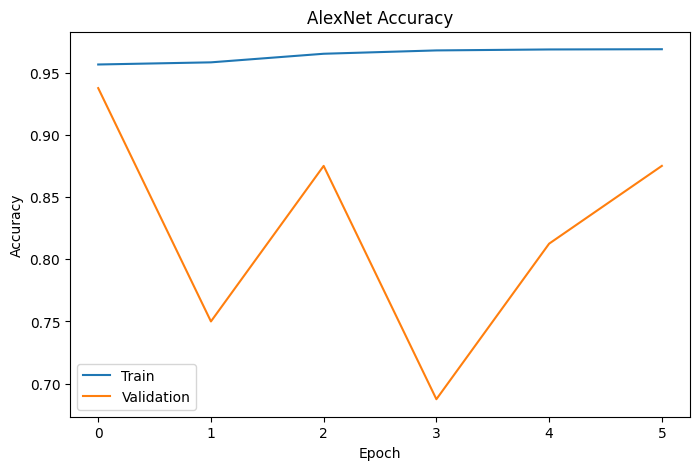

In [22]:
# Plot Accuracy

plt.figure(figsize=(8,5))

plt.plot(train_acc_history,label="Train")
plt.plot(val_acc_history,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("AlexNet Accuracy")

plt.legend()

plt.show()


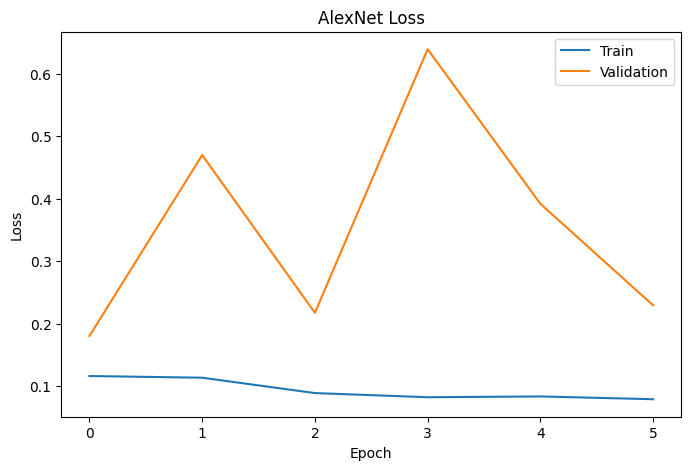

In [23]:
# Plot Loss

plt.figure(figsize=(8,5))

plt.plot(train_loss_history,label="Train")
plt.plot(val_loss_history,label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("AlexNet Loss")

plt.legend()

plt.show()